In [ ]:
!pip install transformers datasets -q

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [ ]:
# ============================================================
# SECTION 1 — DATA CLEANING
# ============================================================
from google.colab import files
uploaded = files.upload()  # select dataset.tsv

Saving dataset.tsv to dataset.tsv


In [ ]:
import pandas as pd

df = pd.read_csv('dataset.tsv', sep='\t')
print("Raw shape:", df.shape)

df['text'] = df['text'].astype(str).str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)
df = df.drop_duplicates(subset='text')
df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.len() > 0]

df_final = df[['text', 'label']].reset_index(drop=True)
print("Cleaned shape:", df_final.shape)
print(df_final['label'].value_counts())

Raw shape: (2356, 4)
Cleaned shape: (2349, 2)
label
1    1178
0    1171
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    df_final, test_size=0.3, stratify=df_final['label'], random_state=42
)
val, test = train_test_split(
    temp, test_size=0.5, stratify=temp['label'], random_state=42
)

train.to_csv('train.csv', index=False)
val.to_csv('val.csv', index=False)
test.to_csv('test.csv', index=False)

print("Train:", train.shape, "Val:", val.shape, "Test:", test.shape)

Train: (1644, 2) Val: (352, 2) Test: (353, 2)


In [ ]:
# ============================================================
# SECTION 2 — NLP MODEL TRAINING (DistilBERT)
# ============================================================
from datasets import Dataset
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(train[['text', 'label']])
val_ds = Dataset.from_pandas(val[['text', 'label']])

def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
train_ds = train_ds.rename_column('label', 'labels')
val_ds = val_ds.rename_column('label', 'labels')
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1644 [00:00<?, ? examples/s]

Map:   0%|          | 0/352 [00:00<?, ? examples/s]

In [ ]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

id2label = {0: "Not Dark Pattern", 1: "Dark Pattern"}
label2id = {"Not Dark Pattern": 0, "Dark Pattern": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=32,      # bigger batch = fewer steps
    per_device_eval_batch_size=32,
    num_train_epochs=3,                   # 3 is usually enough for this dataset size
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=20,
    fp16=True,                            # mixed precision — big speedup on T4
    report_to='none',                     # skip wandb/logging overhead
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.297696,0.158437,0.937500,0.937853,0.937853,0.937853
2,0.100546,0.136589,0.951705,0.944444,0.960452,0.952381
3,0.100726,0.140237,0.948864,0.939227,0.960452,0.949721


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=156, training_loss=0.19103461771439284, metrics={'train_runtime': 42.5499, 'train_samples_per_second': 115.911, 'train_steps_per_second': 3.666, 'total_flos': 163332302542848.0, 'train_loss': 0.19103461771439284, 'epoch': 3.0})

In [ ]:
# Save NLP model
model.save_pretrained('nlp_model')
tokenizer.save_pretrained('nlp_model')
!zip -r nlp_model.zip nlp_model

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: nlp_model/ (stored 0%)
  adding: nlp_model/config.json (deflated 52%)
  adding: nlp_model/tokenizer_config.json (deflated 43%)
  adding: nlp_model/model.safetensors (deflated 8%)
  adding: nlp_model/tokenizer.json (deflated 71%)


In [ ]:
# ============================================================
# SECTION 3 — CV PIPELINE  ⏸️ PARKED — SKIP FOR NOW
# ============================================================
# Uncomment and run this whole section once you have screenshots ready.
# Nothing here depends on anything above except OCR/CV libraries.

RUN_CV_SECTION = False  # flip to True when you're ready

if RUN_CV_SECTION:
    !pip install easyocr opencv-python-headless -q
    import easyocr
    import cv2
    import numpy as np

    reader = easyocr.Reader(['en'], gpu=True)

    def analyze_screenshot(img_path):
        img = cv2.imread(img_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        ocr_results = reader.readtext(img_path)
        texts = [r[1] for r in ocr_results]

        edges = cv2.Canny(gray, 50, 150)
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        button_regions = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > 500]

        region_sizes = [w * h for (x, y, w, h) in button_regions]
        size_variance = np.std(region_sizes) if region_sizes else 0

        return {
            'ocr_text': texts,
            'num_text_regions': len(texts),
            'num_button_regions': len(button_regions),
            'button_size_variance': size_variance,
            'flag_misdirection': size_variance > np.mean(region_sizes) * 2 if region_sizes else False
        }

    urgency_keywords = ['hurry', 'limited time', 'only', 'left', 'ends soon', 'flash sale']
    social_proof_keywords = ['people bought', 'viewed', 'added to cart', 'in demand']

    def keyword_flag(texts):
        joined = ' '.join(texts).lower()
        flags = []
        if any(k in joined for k in urgency_keywords):
            flags.append('Urgency/Scarcity')
        if any(k in joined for k in social_proof_keywords):
            flags.append('Social Proof')
        return flags

    # Optional: test on an uploaded screenshot
    uploaded_img = files.upload()
    for fname in uploaded_img.keys():
        res = analyze_screenshot(fname)
        print(f"\n=== {fname} ===")
        print("Extracted text:", res['ocr_text'])
        print("Button regions:", res['num_button_regions'])
        print("Misdirection flag:", res['flag_misdirection'])
        print("Keyword flags:", keyword_flag(res['ocr_text']))

    # Save CV pipeline as a standalone script
    cv_pipeline_code = '''
import easyocr, cv2, numpy as np
reader = easyocr.Reader(["en"], gpu=True)

def analyze_screenshot(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ocr_results = reader.readtext(img_path)
    texts = [r[1] for r in ocr_results]
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    button_regions = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > 500]
    return {"ocr_text": texts, "num_button_regions": len(button_regions)}
'''
    with open('cv_pipeline.py', 'w') as f:
        f.write(cv_pipeline_code)

    files.download('cv_pipeline.py')

else:
    print("CV section skipped — set RUN_CV_SECTION = True when screenshots are ready.")

CV section skipped — set RUN_CV_SECTION = True when screenshots are ready.


In [ ]:
# ============================================================
# SECTION 4 — EVALUATION (NLP only, for now)
# ============================================================
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

preds, probs = [], []
for text in test['text']:
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        prob = torch.softmax(logits, dim=1)[0][1].item()
    preds.append(logits.argmax().item())
    probs.append(prob)

test['predicted'] = preds
test['confidence'] = probs

print(classification_report(test['label'], test['predicted'], target_names=['Not Dark Pattern', 'Dark Pattern']))

                  precision    recall  f1-score   support

Not Dark Pattern       0.98      0.97      0.97       176
    Dark Pattern       0.97      0.98      0.97       177

        accuracy                           0.97       353
       macro avg       0.97      0.97      0.97       353
    weighted avg       0.97      0.97      0.97       353



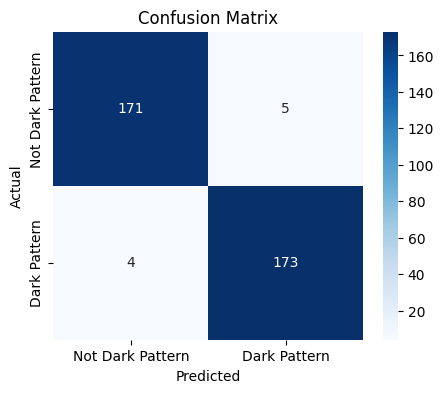

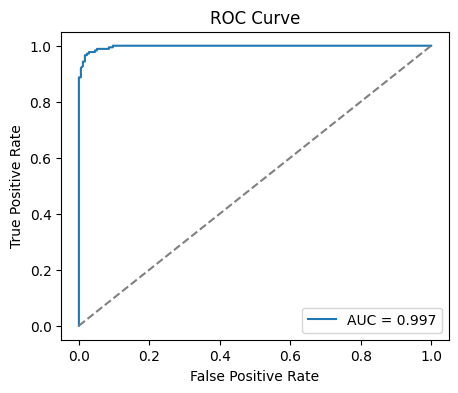

ROC-AUC: 0.9973


In [ ]:
# Confusion matrix
cm = confusion_matrix(test['label'], test['predicted'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Dark Pattern', 'Dark Pattern'],
            yticklabels=['Not Dark Pattern', 'Dark Pattern'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
auc = roc_auc_score(test['label'], test['confidence'])
fpr, tpr, _ = roc_curve(test['label'], test['confidence'])
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc:.4f}")
test.to_csv('test_predictions.csv', index=False)

In [ ]:
# ============================================================
# SECTION 5 — DOWNLOAD DELIVERABLES
# ============================================================
files.download('nlp_model.zip')
files.download('confusion_matrix.png')
files.download('roc_curve.png')
files.download('test_predictions.csv')

# cv_pipeline.py will download automatically once you flip RUN_CV_SECTION = True above

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Run this in Colab — bundles everything into one zip and downloads it to your local machine
import os
import zipfile
from google.colab import files

# List all the files you want to grab
deliverables = [
    'nlp_model.zip',
    'confusion_matrix.png',
    'roc_curve.png',
    'test_predictions.csv'
]

# Check what actually exists in this session
existing = [f for f in deliverables if os.path.exists(f)]
missing = [f for f in deliverables if not os.path.exists(f)]

if missing:
    print("⚠️ Not found in this session (skipped):", missing)

# Bundle into one zip
bundle_name = 'dark_pattern_deliverables.zip'
with zipfile.ZipFile(bundle_name, 'w') as zipf:
    for f in existing:
        zipf.write(f)

print(f"\n✅ Bundled {len(existing)} files into {bundle_name}")

# Trigger the download to your local machine
files.download(bundle_name)